In [1]:
import os, glob
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

os.chdir(os.path.expanduser("~/projects/iride_onboard-burnscar-mapper"))

PHI_OUT, HEO_OUT = "data/PHI", "data/HEO"
BAND_NAMES = ["B", "G", "R", "RE1", "RE2", "RE3", "NIR"]
QUANTIFICATION = {"phisat2_sim": 10000.0, "heo": 4094.0}
MASK_NODATA = 255
SAMPLE_PER_IMAGE = 200_000       # random valid px sampled per scene, per band
MAX_TOTAL_SAMPLES = 5_000_000    # cap per source per band - bounds memory
RNG_SEED = 42

In [2]:
def accumulate_source_stats(images_dir, masks_dir, source, scale,
                            sample_per_image=SAMPLE_PER_IMAGE,
                            max_total_samples=MAX_TOTAL_SAMPLES, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    n_bands = len(BAND_NAMES)
    agg = {b: {"count": 0, "sum": 0.0, "sumsq": 0.0} for b in range(n_bands)}
    samples = {b: [] for b in range(n_bands)}
    budget = {b: max_total_samples for b in range(n_bands)}
    n_scenes = 0

    for ip in sorted(glob.glob(f"{images_dir}/*_img.tif")):
        scene_id = os.path.basename(ip).replace("_img.tif", "")
        mp = f"{masks_dir}/{scene_id}_mask.tif"
        if not os.path.exists(mp): continue
        with rasterio.open(ip) as s: img = s.read()
        with rasterio.open(mp) as s: msk = s.read(1)
        valid_px = msk != MASK_NODATA
        if not valid_px.any(): continue
        n_scenes += 1

        for b in range(n_bands):
            refl = img[b][valid_px].astype(np.float64) / scale
            good = (refl > 0) & (refl <= 1.5)
            refl = refl[good]
            if refl.size == 0: continue
            agg[b]["count"] += refl.size
            agg[b]["sum"] += refl.sum()
            agg[b]["sumsq"] += (refl ** 2).sum()
            if budget[b] > 0:
                take = min(sample_per_image, refl.size, budget[b])
                idx = rng.choice(refl.size, size=take, replace=False)
                samples[b].append(refl[idx].astype(np.float32))
                budget[b] -= take

    samples = {b: (np.concatenate(v) if v else np.array([], np.float32))
              for b, v in samples.items()}
    print(f"{source}: {n_scenes} scenes processed")
    return agg, samples

In [3]:
agg_phi, samp_phi = accumulate_source_stats(f"{PHI_OUT}/images", f"{PHI_OUT}/masks",
                                            "phisat2_sim", QUANTIFICATION["phisat2_sim"])
agg_heo, samp_heo = accumulate_source_stats(f"{HEO_OUT}/images", f"{HEO_OUT}/masks",
                                            "heo", QUANTIFICATION["heo"])

phisat2_sim: 382 scenes processed
heo: 25 scenes processed


In [4]:
def finalize_table(agg, samples, source):
    rows = []
    for b, name in enumerate(BAND_NAMES):
        c, s, sq = agg[b]["count"], agg[b]["sum"], agg[b]["sumsq"]
        mean = s / c if c else np.nan
        std = np.sqrt(max(sq / c - mean**2, 0)) if c else np.nan
        samp = samples[b]
        p1, p50, p99 = (np.percentile(samp, [1, 50, 99]) if samp.size else (np.nan,)*3)
        rows.append(dict(source=source, band=name, n_pixels=c, mean=mean, std=std,
                         p1=p1, p50=p50, p99=p99, n_samples=samp.size))
    return pd.DataFrame(rows)

table = pd.concat([finalize_table(agg_phi, samp_phi, "phisat2_sim"),
                   finalize_table(agg_heo, samp_heo, "heo")], ignore_index=True)
table.to_csv("data/source_stats_comparison.csv", index=False)
pd.set_option("display.width", 160)
print(table.round(4).to_string(index=False))

     source band   n_pixels   mean    std     p1    p50    p99  n_samples
phisat2_sim    B 6073541937 0.1169 0.0347 0.0730 0.1095 0.2057    5000000
phisat2_sim    G 6073550843 0.1109 0.0431 0.0484 0.1030 0.2265    5000000
phisat2_sim    R 6073527790 0.1162 0.0639 0.0264 0.1017 0.2977    5000000
phisat2_sim  RE1 6073555678 0.1350 0.0627 0.0223 0.1273 0.3113    5000000
phisat2_sim  RE2 6073561095 0.1867 0.0724 0.0197 0.1999 0.3487    5000000
phisat2_sim  RE3 6073517095 0.2143 0.0847 0.0177 0.2316 0.4016    5000000
phisat2_sim  NIR 6073550234 0.2109 0.0851 0.0143 0.2286 0.3981    5000000
        heo    B  482601811 0.2206 0.1557 0.0713 0.1532 0.5857    5000000
        heo    G  483590360 0.2438 0.2049 0.0613 0.1624 0.7782    5000000
        heo    R  493460498 0.2404 0.2102 0.0415 0.1615 0.8146    5000000
        heo  RE1  507107641 0.1732 0.0985 0.0247 0.1566 0.4184    5000000
        heo  RE2  499822829 0.3775 0.2912 0.0503 0.2807 1.2604    5000000
        heo  RE3  489786003 0.2311 0.1

In [5]:
ks_rows = []
for b, name in enumerate(BAND_NAMES):
    a, c = samp_phi[b], samp_heo[b]
    stat, p = ks_2samp(a, c) if (a.size and c.size) else (np.nan, np.nan)
    ks_rows.append(dict(band=name, ks_stat=stat, ks_pvalue=p))
ks_table = pd.DataFrame(ks_rows)
print(ks_table.round(4).to_string(index=False))
# ks_stat near 0 = distributions overlap well; near 1 = they barely overlap

band  ks_stat  ks_pvalue
   B   0.3829        0.0
   G   0.3776        0.0
   R   0.2871        0.0
 RE1   0.1996        0.0
 RE2   0.4142        0.0
 RE3   0.1392        0.0
 NIR   0.4206        0.0


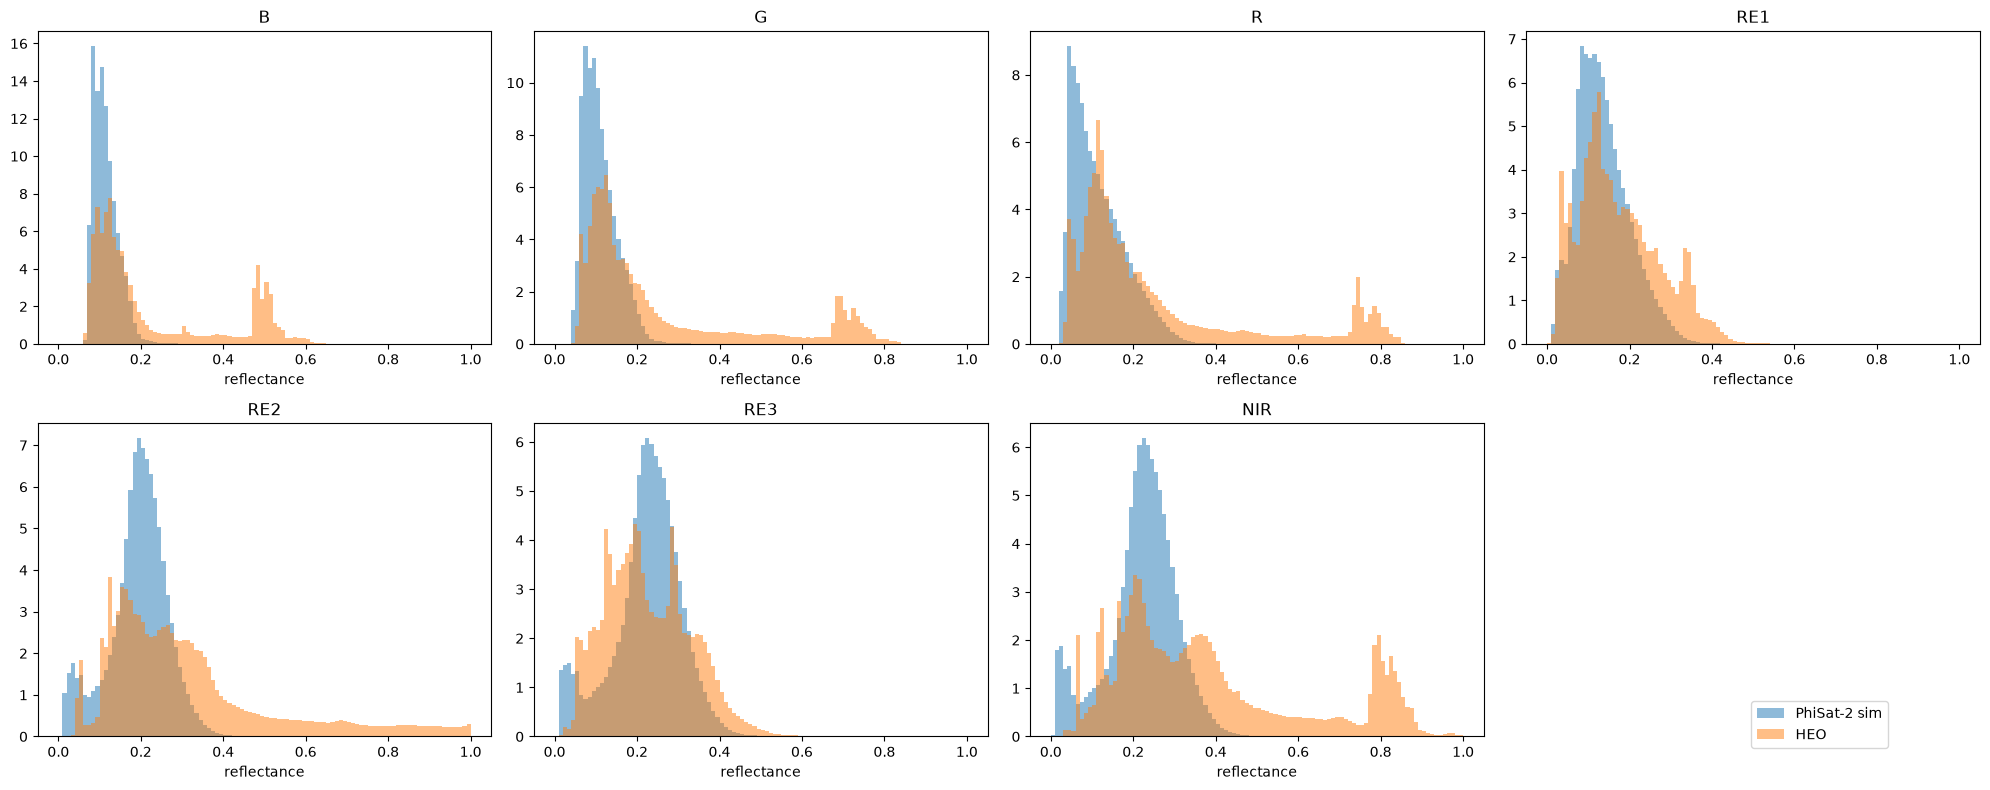

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for b, name in enumerate(BAND_NAMES):
    ax = axes[b]
    if samp_phi[b].size: ax.hist(samp_phi[b], bins=100, range=(0,1), alpha=0.5,
                                 density=True, color="tab:blue", label="PhiSat-2 sim")
    if samp_heo[b].size: ax.hist(samp_heo[b], bins=100, range=(0,1), alpha=0.5,
                                 density=True, color="tab:orange", label="HEO")
    ax.set_title(name); ax.set_xlabel("reflectance")
axes[-1].axis("off")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower right", bbox_to_anchor=(0.95, 0.05))
plt.tight_layout(); plt.show()

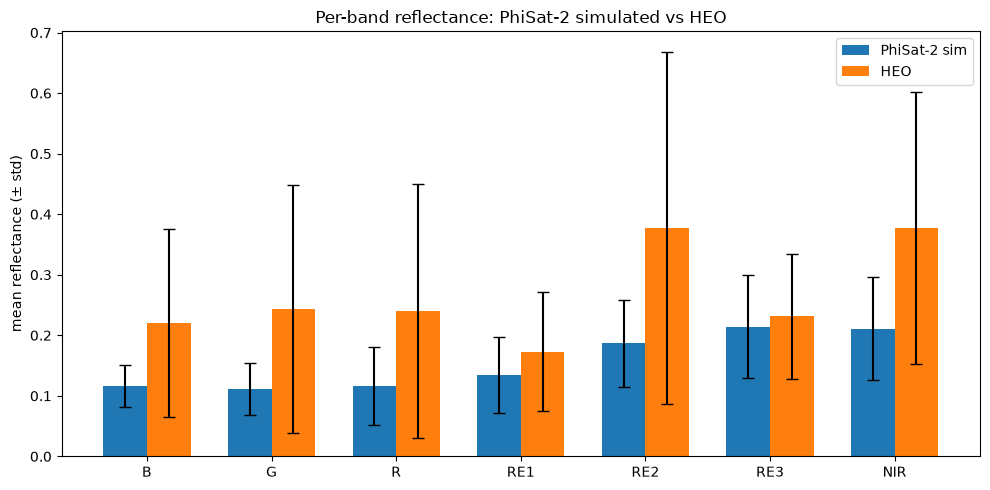

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(BAND_NAMES)), 0.35
phi_row = table[table.source == "phisat2_sim"].set_index("band").loc[BAND_NAMES]
heo_row = table[table.source == "heo"].set_index("band").loc[BAND_NAMES]
ax.bar(x - w/2, phi_row["mean"], width=w, yerr=phi_row["std"], capsize=4, label="PhiSat-2 sim")
ax.bar(x + w/2, heo_row["mean"], width=w, yerr=heo_row["std"], capsize=4, label="HEO")
ax.set_xticks(x); ax.set_xticklabels(BAND_NAMES)
ax.set_ylabel("mean reflectance (± std)")
ax.set_title("Per-band reflectance: PhiSat-2 simulated vs HEO")
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
# Re-run stats conditioned on mask class, to separate "sensor brightness"
# from "this sample happens to have 70x more cloud pixels"
CLASS_GROUPS = {"clear_only": [0], "cloud_only": [4], "water_only": [6]}

def accumulate_by_class(images_dir, masks_dir, source, scale, class_vals,
                        sample_per_image=100_000, max_total_samples=2_000_000, seed=42):
    rng = np.random.default_rng(seed)
    n_bands = len(BAND_NAMES)
    agg = {b: {"count": 0, "sum": 0.0, "sumsq": 0.0} for b in range(n_bands)}
    for ip in sorted(glob.glob(f"{images_dir}/*_img.tif")):
        scene_id = os.path.basename(ip).replace("_img.tif", "")
        mp = f"{masks_dir}/{scene_id}_mask.tif"
        if not os.path.exists(mp): continue
        with rasterio.open(ip) as s: img = s.read()
        with rasterio.open(mp) as s: msk = s.read(1)
        sel = np.isin(msk, class_vals)
        if not sel.any(): continue
        for b in range(n_bands):
            refl = img[b][sel].astype(np.float64) / scale
            good = (refl > 0) & (refl <= 1.5)
            refl = refl[good]
            if refl.size == 0: continue
            agg[b]["count"] += refl.size; agg[b]["sum"] += refl.sum(); agg[b]["sumsq"] += (refl**2).sum()
    rows = []
    for b, name in enumerate(BAND_NAMES):
        c, s, sq = agg[b]["count"], agg[b]["sum"], agg[b]["sumsq"]
        mean = s/c if c else np.nan
        std = np.sqrt(max(sq/c - mean**2, 0)) if c else np.nan
        rows.append(dict(source=source, band=name, mean=mean, std=std, n=c))
    return pd.DataFrame(rows)

for label, vals in CLASS_GROUPS.items():
    t = pd.concat([
        accumulate_by_class(f"{PHI_OUT}/images", f"{PHI_OUT}/masks", "phisat2_sim", QUANTIFICATION["phisat2_sim"], vals),
        accumulate_by_class(f"{HEO_OUT}/images", f"{HEO_OUT}/masks", "heo", QUANTIFICATION["heo"], vals),
    ], ignore_index=True)
    print(f"\n--- {label} ---")
    print(t.round(4).to_string(index=False))


--- clear_only ---
     source band   mean    std          n
phisat2_sim    B 0.1191 0.0350 4650975258
phisat2_sim    G 0.1166 0.0419 4650971493
phisat2_sim    R 0.1244 0.0634 4650956507
phisat2_sim  RE1 0.1470 0.0572 4650975523
phisat2_sim  RE2 0.2089 0.0526 4650982224
phisat2_sim  RE3 0.2414 0.0607 4650945323
phisat2_sim  NIR 0.2379 0.0610 4650972302
        heo    B 0.1563 0.1111  291634284
        heo    G 0.1846 0.1740  292300746
        heo    R 0.1948 0.1920  296854368
        heo  RE1 0.1696 0.1013  303118851
        heo  RE2 0.3254 0.2825  300806222
        heo  RE3 0.2438 0.1067  297914299
        heo  NIR 0.3264 0.1859  298282750
